In [1651]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [1652]:
df=pd.read_csv("ford.csv")

In [1653]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [1654]:
df.shape

(17966, 9)

In [1655]:
df.drop_duplicates(inplace=True)

In [1656]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


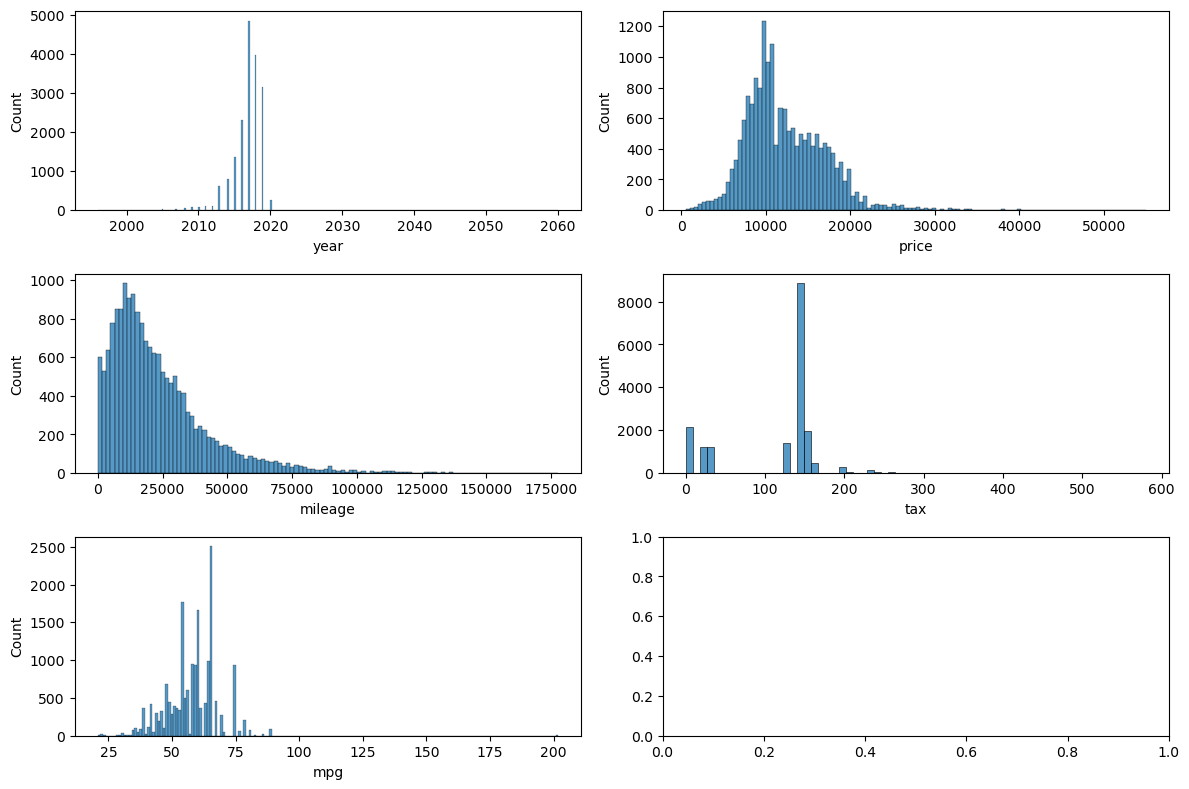

In [1657]:
cols=["year","price","mileage","tax","mpg",]
fig,ax=plt.subplots(3,2,figsize=(12,8))

for i,col in enumerate(cols):
    sns.histplot(data=df,x=col,ax=ax[i//2,i%2])

plt.tight_layout()

<Axes: xlabel='price', ylabel='mileage'>

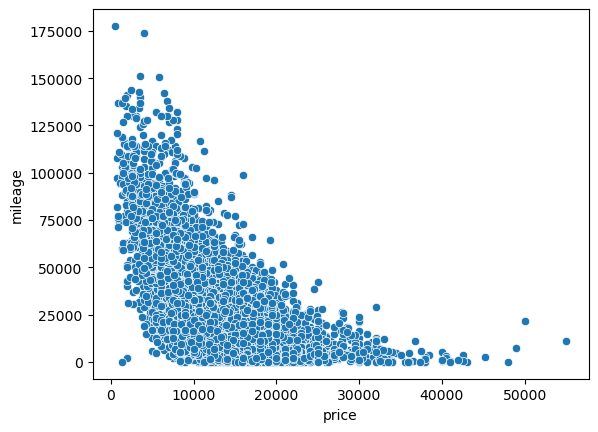

In [1658]:
sns.scatterplot(data=df,x="price",y="mileage")

<Axes: xlabel='price', ylabel='year'>

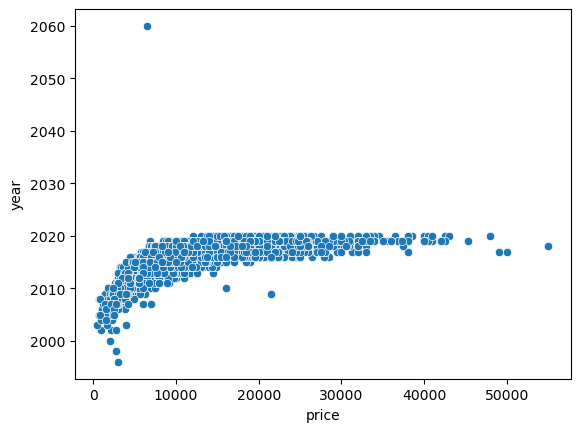

In [1659]:
sns.scatterplot(data=df,x="price",y="year")

In [1660]:
df[df["tax"]>500].shape

(12, 9)

<Axes: xlabel='mileage', ylabel='Count'>

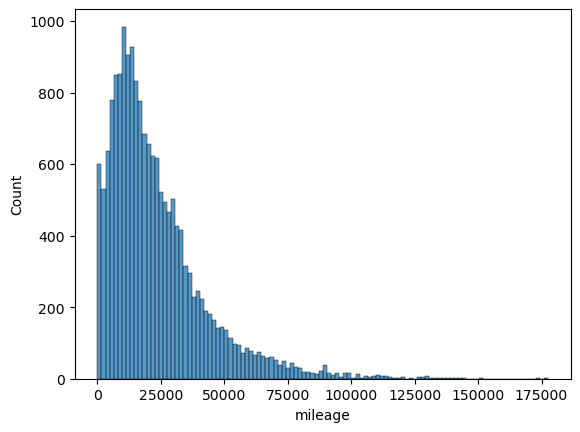

In [1661]:
sns.histplot(data=df,x="mileage")

In [1662]:
df["price_log"]=np.log(df["price"])


In [1663]:
df=df.drop(index=17726)

<Axes: xlabel='price_log', ylabel='Count'>

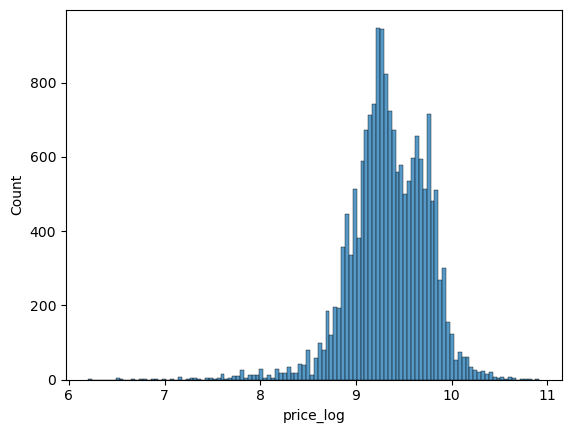

In [1664]:
sns.histplot(data=df,x="price_log")

In [1665]:
corr=df[cols].corrwith(df["price"])
corr

year       0.645236
price      1.000000
mileage   -0.530433
tax        0.406112
mpg       -0.346401
dtype: float64

- tax and year are highly correlated with price


In [1666]:
corr=df.corr(numeric_only=True)

<Axes: >

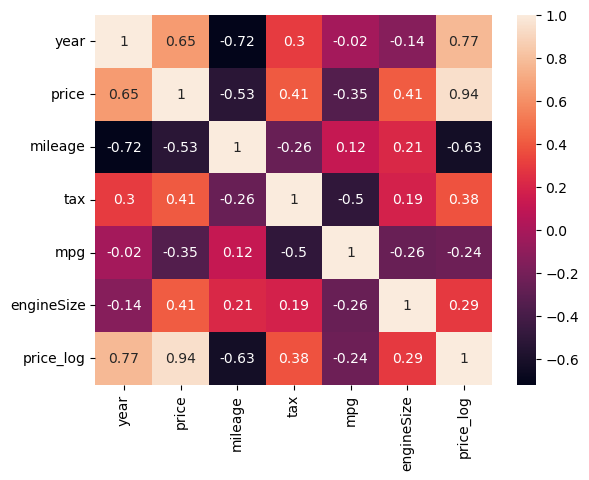

In [1667]:
sns.heatmap(corr,annot=True)

In [1668]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,price_log
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0,9.392662
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0,9.546813
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0,9.472705
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5,9.769956
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0,9.711116


In [1669]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

df[cols]=scaler.fit_transform(df[["year","price","mileage","tax","mpg"]])

In [1670]:
df=pd.get_dummies(df,dtype=int)

In [1671]:
df.columns

Index(['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize', 'price_log',
       'model_ B-MAX', 'model_ C-MAX', 'model_ EcoSport', 'model_ Edge',
       'model_ Escort', 'model_ Fiesta', 'model_ Focus', 'model_ Fusion',
       'model_ Galaxy', 'model_ Grand C-MAX', 'model_ Grand Tourneo Connect',
       'model_ KA', 'model_ Ka+', 'model_ Kuga', 'model_ Mondeo',
       'model_ Mustang', 'model_ Puma', 'model_ Ranger', 'model_ S-MAX',
       'model_ Streetka', 'model_ Tourneo Connect', 'model_ Tourneo Custom',
       'model_ Transit Tourneo', 'model_Focus', 'transmission_Automatic',
       'transmission_Manual', 'transmission_Semi-Auto', 'fuelType_Diesel',
       'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other',
       'fuelType_Petrol'],
      dtype='object')

In [1672]:
cat_features=['engineSize', 'model_ B-MAX', 'model_ C-MAX', 'model_ EcoSport',
       'model_ Edge', 'model_ Escort', 'model_ Fiesta', 'model_ Focus',
       'model_ Fusion', 'model_ Galaxy', 'model_ Grand C-MAX',
       'model_ Grand Tourneo Connect', 'model_ KA', 'model_ Ka+',
       'model_ Kuga', 'model_ Mondeo', 'model_ Mustang', 'model_ Puma',
       'model_ Ranger', 'model_ S-MAX', 'model_ Streetka',
       'model_ Tourneo Connect', 'model_ Tourneo Custom',
       'model_ Transit Tourneo', 'model_Focus', 'transmission_Automatic',
       'transmission_Manual', 'transmission_Semi-Auto', 'fuelType_Diesel',
       'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other',
       'fuelType_Petrol']

In [1673]:
from scipy.stats import chi2_contingency

alpha=0.05

df["price"]=pd.qcut(df["price"],q=4,labels=False)
chi2_results={}

for col in cat_features:
    table=pd.crosstab(df[col],df["price"])
    
    chi2_stat,p,_,_=chi2_contingency(table)

    decision="Reject Null (keep feature)" if p<alpha else "Accept Null (drop feature)"

    chi2_results[col]={
        "chi2_statistics":chi2_stat,
        "p_value":p,
        "Decision":decision
    }

In [1674]:
chi=pd.DataFrame(chi2_results).T
chi=chi.sort_values(by="p_value")

In [1675]:
df=df.drop(columns=['model_ Mondeo', 'fuelType_Electric', 'model_ Streetka',
       'model_ Ranger', 'model_ Transit Tourneo', 'fuelType_Other',
       'model_Focus', 'model_ Escort'])

In [1676]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score, classification_report


X=df.drop(["price_log","price"],axis=1)
Y=df["price_log"]

X_train, X_test, y_train, y_test=train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

model=LinearRegression()

model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [1677]:
y_pred=model.predict(X_test)

In [1678]:
y_pred

array([9.6779041 , 7.82016153, 9.53483321, ..., 9.35334739, 9.22578578,
       9.56915276], shape=(3563,))

In [1679]:
# print("Accuracy:", accuracy_score(y_test, y_pred))
# print(classification_report(y_test, y_pred))

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)



n=X_test.shape[0]
p=X_test.shape[1]

adjusted_r2= 1-((1-r2)*(n-1)/(n-p-1))

MAE : 0.09614497884967367
MSE : 0.015709123744584018
RMSE: 0.12533604327799733
R² Score: 0.9032368826491897


In [1680]:
adjusted_r2

0.9024426198687839